In [91]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [92]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

##### Görev 1
Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın. İstersen videodaki gibi computation graph'i graphviz ile çizdir. (19:09 - 32:10)

Bu görevde amacımız sonraki görevlerde kolaylık sağlaması için Value classımızı yazmak. Basit işlemleri yapmamızda ve görselleştirmemizzde yardımcı olacak. Kritik nokta geçmiş değerleri tutabilmesi, geçmiş değerleri tutulması ile geriyedönük işlemler yapabileceğiz backpropagation için.

bu kısımda manuel bir şekilde türevleri bulabiliriz.

In [93]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._op = _op
        self.label = label
        self._backward = lambda: None  # fonksiyonun geri yayılımını başlatmak için bir lambda fonksiyonu tanımladık


    def __repr__(self):
        return f"Value({self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward(): # görev 3 için toplama fonksiyonunun türevini ekledik
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward(): # görev 3 için çarpma fonksiyonunun türevini ekledik
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    #görev 2 içim tanh fonksiyonunu ekledik
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward(): #görev 3 için tanh fonksiyonunun türevini ekledik
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    # görev 3 için backward fonksiyonunu 
    def backward(self):
        # topolojik sıralama ile geri yayılımı başlatmak için bir fonksiyon tanımladık
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    # görev 4 için pow, exp, truediv, sub ve neg fonksiyonlarını ekledik
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out          

    def __truediv__(self, other):
        return self * other**-1

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other


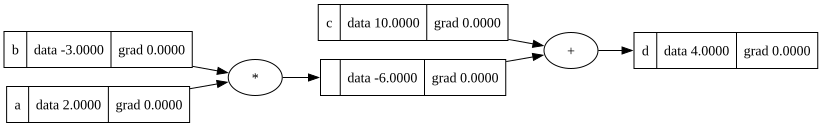

In [94]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

d = a* b + c 
d.label='d'

draw_dot(d)

##### Görev 2
Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur: önce basit ifade (32:10 - 51:10), sonra tek bir neuron. Neuron örneğinde tanh'ı Value'ya ekleyeceksin. Chain rule'u burada içselleştireceksin. (52:52 - 1:09:02)

(f(x+h) - f(x)) / h

gradyan check, zincir kuralı

bu kısımda amaç manuel bir şekilde türevleri adım adım bulmak ardından daha uzak noktalardaki örneğin aralarında 2 3 adım bulunan noktaların türevini bulabilmek. Zincir kuralı ile bu yapıyı kurarız. 

basitçe karpathynin örneği gibi:
insan = 2x 
bisiklet = 4 * insan        +
otobüs = 8 * bisiklet

basitçe kafamızda zincirleme yapıp otobüsün insandan 64x hızlı olduğunu görürüz.

işlemsel olarak bunları bilmekteyiz:
dL / dd
dd / dc

amacımız ise bunu bulabilmek:
dL / dc  yani =>  (dL / dd) x (dd / dc)

yani aslında otobüs ve insan arasındaki ilişkiyi görebilmek doğrudan sırayla yapmak yerine.

yerel türevler:

1. toplama işlemi: d = a + b
    burada a'yı 1 birim arttırırsam d de 1 birim artar yani d'nin a'ya türevi 1
    aynı şekilde b'yi 1 birim arttırırsam d de 1 birim artar yani d'nin b'ye türevi 1
    yani toplama işlemi gelen gradyanı olduğu gibi geriye iter (gradyan dağıtıcı, router)

2. çarpma işlemi: e = a x b
    a'yı 1 birim arttırırsam e, b kadar artar yani e'nin a'ya türevi b'dir
    b'yi 1 birim arttırırsam e, a kadar artar yani e'nin b'ye türevi a'dır
    yani çarpma işlemi girdilerin değerlerini çapraz olarak yer değiştirir (gradyan anahtarlayıcı, switcher)

3. tanh aktivasyonu: o = tanh(n)
     standart türev: do / dn = 1 -tanh^2(n) = 1 - o^2
     yani tanh'In çıktısını biliyorsak (o) türevi doğrudan 1 - o^2 olur
     



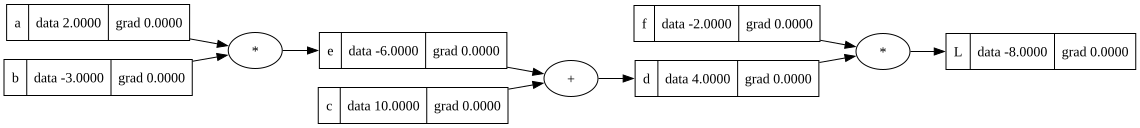

In [95]:
#manuel gradyanları atamak için örneğimiz, gradlarımız 0 gördüğünüz gibi

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b;             e.label = 'e'
d = e + c;             d.label = 'd'
f = Value(-2.0, label='f')
L = d * f;             L.label = 'L'

draw_dot(L)

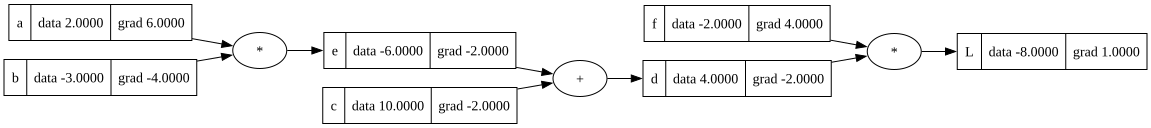

In [96]:
#örneğimize atamalarımı yaptığım kısımlar ve işlemlerim

# kendine göre türevden L'nin L'ye göre türevi her zaman 1'dir.
L.grad = 1.0

# L = d x f için :
# f nesnemiz için: dL/dd = d.data x L.grad = -2 x 4 = -2
d.grad = f.data * L.grad
# d nesnemiz için: dL /df = f.data x L.grad = -2 x 1 = -2
f.grad = d.data * L.grad


# d = e + c için:
# zincir kuralı uygularız, üstten d'ye gelen gradyan d.grad= -2'dir
# e'nin yerel türevi dd/de = 1dir
e.grad = 1.0 * d.grad # = -2

#c'nin yerel türevi dd/dc = 1dir
c.grad = 1.0 * d.grad # = -2



# e = a x b için:
#yine zincir kuralı
# üstten e'ye gelen gradye e.grad = -2dir
a.grad = b.data * e.grad # =6
b.grad = a.data * e.grad #-4

draw_dot(L)

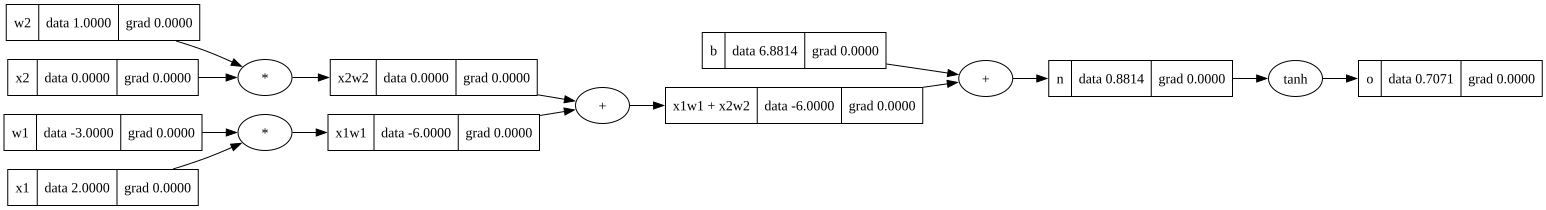

In [97]:
#bu kısımda tek bir nöron ve tanh denklemini kurucaz
# manuel bir şekilde bir nörondaki gradyanları hesaplayacağız

#ilk olarak value sınıfımıza tanh metodunu ekledik, deneyelim
# mantıksal olarak formul => n = x1.w1 + x2.w2 + b  ve o = tanh(n) şeklinde olacak

# girdiler x, ağırlıklar w ve bias b değerlerini value sınıfından türettik
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')    
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b') 

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

#tanh fonksiyonunu uygulayalım
o = n.tanh(); o.label = 'o'

draw_dot(o)



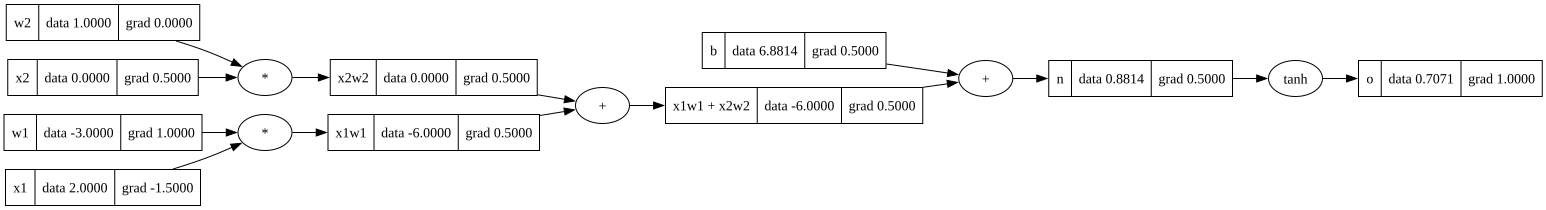

In [98]:
# örneğmizi oluşturduk, şimdi manuel bir şekilde gradyanları hesaplayalım geriye doğru

o.grad = 1.0 # output gradımız 1 

# tanh fonksiyonunun türevini alalım, tanh'(x) = 1 - tanh(x)^2
n.grad = (1 - o.data**2) * o.grad # 0.5

# zincir kuralı ile n = x1.w1 + x2.w2 + b için gradyanları hesaplayalım
# üstten n'ye gelen gradyan n.grad = 0.5'tir
x1w1x2w2.grad = n.grad #0.5
b.grad = n.grad #0.5

# toplam kapılarının gradyanlarını hesaplayalım n = x1w1x2w2 + b için
x1w1.grad = x1w1x2w2.grad # = 0.5
x2w2.grad = x1w1x2w2.grad # = 0.5

# çarpım kapılarının gradyanlarını hesaplayalım x1w1 = x1 * w1 ve x2w2 = x2 * w2 için
x1.grad = w1.data * x1w1.grad # = -1.5
w1.grad = x1.data * x1w1.grad # = 1
x2.grad = w2.data * x2w2.grad # = 0.5
w2.grad = x2.data * x2w2.grad # = 0

draw_dot(o)


##### Görev 3
backward() metodunu yaz: çıktının gradient'ini 1 yap, node'ları ters topological sırayla gez, her node'da chain rule uygula. Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma. (1:09:02 - 1:27:05)

bu kısımda yaptığımız manuel atamalar yerine otomatik tek bir metod yazacağız
her seferinde elle gradyan hesaplamak yerine o.backward() çağırdığımızda kendi yapacak

ilk olarak Value sınıfımıza _backward metodunu eklememiz gerekli. örneğin __add__ içinde yeni out nesnesi türetirken o nesneye ait bir de def _backward() fonksiyonunu tanımlamalıyız. diğer fonksiyonlarda da backward mantıklarını eklememiz gerekir.

topolojil sıralama: ağaçtaki bir düğümün gradyanını hesaplamadan önce o düğümün tüm çocukları hesaplanmış olmalı

o düğümünden yani en sonundcudan başlayarak tek yönlü sıralı graf listesi dizen ve bu listeyi tersten gezip her düğümde _backward() çağırmamız gerekir

önemli olan nokta bir düğüm birden fazla yerde kullanılıyorsa gradyanların üzerine yazılmamalı, toplanmalıdır self.grad += gibi


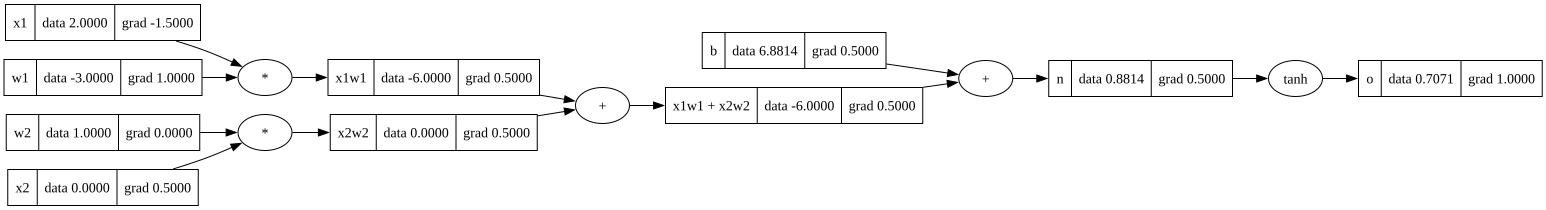

In [99]:
# Backpropagation fonksiyonunu manuel olarak yaptık, şimdi bunu otomatik bir şekilde yapalım
# az önceki örneğimizdeki nöronda deneyelim 

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')    
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b') 

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'


o.backward() # backward otomatik bir şekilde gradyanları hesaplayacak

draw_dot(o)


#### Görev 4
tanh'ı parçala: exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster. Sonra doğrula: aynı ifadeyi aynı değerlerle hem backward() ile hem geçen haftaki numerical derivative ile hem de PyTorch ile hesapla, üçünün eşleştiğini göster. (1:27:05 - 1:43:55)

$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

tanh gösterimi matematiksel olarak bu şekildedir.
Bu parçayı açabilmek için manuel bir şekilde bazı operatörleri eklememiz gerekir sınıfımıza = exp, pow, truediv, sub, neg. ardından sırayla şimdiye kadar uyguladığımız yöntemlerle ve kütüphane ile de test edeceğiz.

In [100]:
# aynı şekilde önceki örneğimizi kullanalım
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')    
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b') 

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# Parçalanmış tanh: (e^(2n) - 1) / (e^(2n) + 1)
e = (2 * n).exp()
o = (e - 1) / (e + 1)
o.backward()

print("Kendi motorumuz - x1.grad:", x1.grad)
print("Kendi motorumuz - w1.grad:", w1.grad)
print("Kendi motorumuz - x2.grad:", x2.grad)
print("Kendi motorumuz - w2.grad:", w2.grad)
print("Kendi motorumuz - b.grad:", b.grad)


Kendi motorumuz - x1.grad: -1.5
Kendi motorumuz - w1.grad: 1.0
Kendi motorumuz - x2.grad: 0.5
Kendi motorumuz - w2.grad: 0.0
Kendi motorumuz - b.grad: 0.5


In [101]:
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [102]:
# pytorch ile aynı örneği deneyelim
import torch

x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(6.8813735870195432, requires_grad=True)

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

o.backward()

print("PyTorch - x1.grad:", x1.grad.item())
print("PyTorch - w1.grad:", w1.grad.item()) 
print("PyTorch - x2.grad:", x2.grad.item())
print("PyTorch - w2.grad:", w2.grad.item())
print("PyTorch - b.grad:", b.grad.item())



PyTorch - x1.grad: -1.5000003576278687
PyTorch - w1.grad: 1.000000238418579
PyTorch - x2.grad: 0.5000001192092896
PyTorch - w2.grad: 0.0
PyTorch - b.grad: 0.5000001192092896


#### Görev 5
Videodaki sırayı izleyerek Neuron, Layer ve MLP sınıflarını kur. Parametreleri tek listede topla, videodaki küçük veri setiyle eğit, loss'un adım adım düştüğünü göster. Her adımda gradient'leri sıfırlamayı unutma, videodaki meşhur bug. (1:43:55 - 2:14:03)

kurgumuzda bir sorun olmadığı için tam simülasyonu kurgulayabiliriz artık.
sinir ağımız için gerekli neuron, layer, mlp sınıflarını tasarlayacağız ve model eğitimi yapacağız en sonunda

In [103]:
# sınıflarımız

import random   

class Neuron:
    def __init__(self, num):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(num)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, inputs):
        n = sum((w * i for w, i in zip(self.w, inputs)), self.b)
        o = n.tanh()
        return o

    def parameters(self):
        return self.w + [self.b]
    


class Layer:
    def __init__(self, num_inputs, num_neurons):
        self.neurons = [Neuron(num_inputs) for _ in range(num_neurons)]

    def __call__(self, inputs):
        outputs = [neuron(inputs) for neuron in self.neurons]
        return outputs[0] if len(outputs) == 1 else outputs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

class MLP:
        def __init__(self, num_inputs, nouts):
            sz = [num_inputs] + nouts
            self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

        def __call__(self, x):
            for layer in self.layers:
                x = layer(x)
            return x

        def parameters(self):
            return [p for layer in self.layers for p in layer.parameters()]

In [104]:
# Veri seti
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

# 3 girdili, iki adet 4'lük gizli katmanlı ve 1 çıktılı model
model = MLP(3, [4, 4, 1])

# Eğitim döngüsü
for k in range(20):
    # 1. Forward pass , tahmin
    ypred = [model(x) for x in xs]
    
    #Loss hesabı
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # sıfırlama 
    for p in model.parameters():
        p.grad = 0.0
        
    # 4. backward pass
    loss.backward()
    
    # 5. Güncelleme
    for p in model.parameters():
        p.data += -0.05 * p.grad
        
    print(f"Adım {k+1} | Loss: {loss.data:.4f}")


Adım 1 | Loss: 5.3119
Adım 2 | Loss: 4.0214
Adım 3 | Loss: 3.6125
Adım 4 | Loss: 3.1637
Adım 5 | Loss: 2.5030
Adım 6 | Loss: 1.4445
Adım 7 | Loss: 0.6519
Adım 8 | Loss: 0.3545
Adım 9 | Loss: 0.2372
Adım 10 | Loss: 0.1762
Adım 11 | Loss: 0.1390
Adım 12 | Loss: 0.1141
Adım 13 | Loss: 0.0965
Adım 14 | Loss: 0.0834
Adım 15 | Loss: 0.0732
Adım 16 | Loss: 0.0652
Adım 17 | Loss: 0.0587
Adım 18 | Loss: 0.0533
Adım 19 | Loss: 0.0488
Adım 20 | Loss: 0.0449


In [107]:
for k in range(20):
    print(f"Adım {k+1} | Loss: {loss.data:.4f} | grad: {[p.grad for p in model.parameters()]}")

Adım 1 | Loss: 0.0449 | grad: [-0.002973422130796719, 0.0019944336262003653, -0.005913768540215347, 0.0030402080001552664, 9.550427059324199e-05, -0.001284359352258201, -0.006900427476575807, -0.0016306561517623534, -0.03652515880819318, -0.001816769469446304, -0.07344778996155371, -0.030215075589895286, -0.013426458552316714, -0.01419330246644796, 0.017402366189460346, -0.012656447853229108, 0.00366630622381258, 0.0006537544742396912, 0.01072180943324976, 0.0038875934220848523, -7.756895415018342e-05, -0.030706411550314543, 1.4161297605501388e-05, -0.08690049279324649, -0.02503405478638869, -0.006317380944993671, 0.034341933453056424, 0.0017095089740182326, 0.10034325121281308, 0.03108084823422186, 0.004414295589868195, 0.018321631161146303, -0.00059834753186477, 0.042832633982365004, 0.019356668621139387, 0.0039471332272061135, 0.06588591446044174, 0.07472410332472956, -0.10718376061231744, -0.10969839349704899, -0.048543448897980936]
Adım 2 | Loss: 0.0449 | grad: [-0.002973422130796